<a href="https://colab.research.google.com/github/2303A52261/Explainable-AI/blob/main/EAI_LAB_EXM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Import pandas library
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/Avian Influenza (HPAI).csv")

# Print the entire dataset
print(df)

# (Optional) – To just view the first 5 rows for quick look
# print(df.head())


         _id          Scientific_Name            Common_Name  \
0          1  Acrocephalus scirpaceus  Eurasian Reed Warbler   
1          2  Acrocephalus scirpaceus  Eurasian Reed Warbler   
2          3        Limosa haemastica       Hudsonian Godwit   
3          4        Limosa haemastica       Hudsonian Godwit   
4          5        Limosa haemastica       Hudsonian Godwit   
...      ...                      ...                    ...   
16299  16300          Aythya collaris       Ring-necked Duck   
16300  16301          Aythya collaris       Ring-necked Duck   
16301  16302       Larus delawarensis       Ring-billed Gull   
16302  16303       Larus delawarensis       Ring-billed Gull   
16303  16304       Larus delawarensis       Ring-billed Gull   

                      Date  Year  Month  Day  Time  Country  \
0      2015-09-15T00:00:00  2015      9   15  1100  Ireland   
1      2015-09-15T00:00:00  2015      9   15  1100  Ireland   
2      2015-09-15T00:00:00  2015      9   

In [9]:
import pandas as pd

# Load the dataset with low_memory=False to avoid dtype warnings
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False)

# Convert all string/object columns to numeric (non-convertible values become NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Print the first few rows to confirm conversion
print(df.head())

# Optional: Check data types after conversion
print("\nData types after conversion:\n", df.dtypes)


   _id  Scientific_Name  Common_Name  Date  Year  Month  Day  Time  Country  \
0    1              NaN          NaN   NaN  2015      9   15  1100      NaN   
1    2              NaN          NaN   NaN  2015      9   15  1100      NaN   
2    3              NaN          NaN   NaN  2015      9   15  1100      NaN   
3    4              NaN          NaN   NaN  2015      9   15  1100      NaN   
4    5              NaN          NaN   NaN  2015      9   15  1100      NaN   

   Country_State_County  State  County  Locality  Latitude  Longitude  \
0                   NaN    NaN     NaN       NaN   53.1291    -9.7507   
1                   NaN    NaN     NaN       NaN   53.1291    -9.7507   
2                   NaN    NaN     NaN       NaN   53.1291    -9.7507   
3                   NaN    NaN     NaN       NaN   53.1291    -9.7507   
4                   NaN    NaN     NaN       NaN   53.1291    -9.7507   

   Parent_Species  target_H5_HPAI  
0             NaN               0  
1             

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1️⃣ Load dataset
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False)

# 2️⃣ Display basic info
print("Initial Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())

# 3️⃣ Convert numeric-like columns automatically
# Convert any column that can be converted into numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

# 4️⃣ Encode categorical columns
# Select all object-type columns (strings)
cat_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 5️⃣ Handle missing values
# Replace NaN with column mean for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# 6️⃣ Display processed dataset info
print("\nProcessed Shape:", df.shape)
print("\nData types after preprocessing:\n", df.dtypes)

# 7️⃣ View first 5 rows
print("\nSample of processed data:\n", df.head())


Initial Shape: (16304, 17)

Missing values per column:
 _id                       0
Scientific_Name           0
Common_Name               0
Date                      0
Year                      0
Month                     0
Day                       0
Time                      0
Country                   0
Country_State_County      0
State                     0
County                  129
Locality                  0
Latitude                  0
Longitude                 0
Parent_Species            0
target_H5_HPAI            0
dtype: int64

Processed Shape: (16304, 17)

Data types after preprocessing:
 _id                       int64
Scientific_Name           int64
Common_Name               int64
Date                      int64
Year                      int64
Month                     int64
Day                       int64
Time                      int64
Country                   int64
Country_State_County      int64
State                     int64
County                    int64
Localit

/tmp/ipython-input-822554021.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [11]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False)

# Print count of null (missing) values in each column
print("Null values in each column:\n")
print(df.isnull().sum())

# Optional: show only columns that actually have missing values
print("\nColumns with missing values only:\n")
print(df[df.columns[df.isnull().any()]].isnull().sum())


Null values in each column:

_id                       0
Scientific_Name           0
Common_Name               0
Date                      0
Year                      0
Month                     0
Day                       0
Time                      0
Country                   0
Country_State_County      0
State                     0
County                  129
Locality                  0
Latitude                  0
Longitude                 0
Parent_Species            0
target_H5_HPAI            0
dtype: int64

Columns with missing values only:

County    129
dtype: int64


Columns in the dataset:

Index(['_id', 'Scientific_Name', 'Common_Name', 'Date', 'Year', 'Month', 'Day',
       'Time', 'Country', 'Country_State_County', 'State', 'County',
       'Locality', 'Latitude', 'Longitude', 'Parent_Species',
       'target_H5_HPAI'],
      dtype='object')

Class Distribution for 'Scientific_Name':

Scientific_Name
Erithacus rubecula                   420
Chroicocephalus ridibundus           332
Corvus frugilegus                    278
Larus argentatus                     276
Cygnus olor                          273
                                    ... 
Anas crecca crecca x carolinensis      1
Chordeiles minor                       1
Ardea alba alba                        1
Catharus ustulatus                     1
Numenius phaeopus/arquata              1
Name: count, Length: 410, dtype: int64


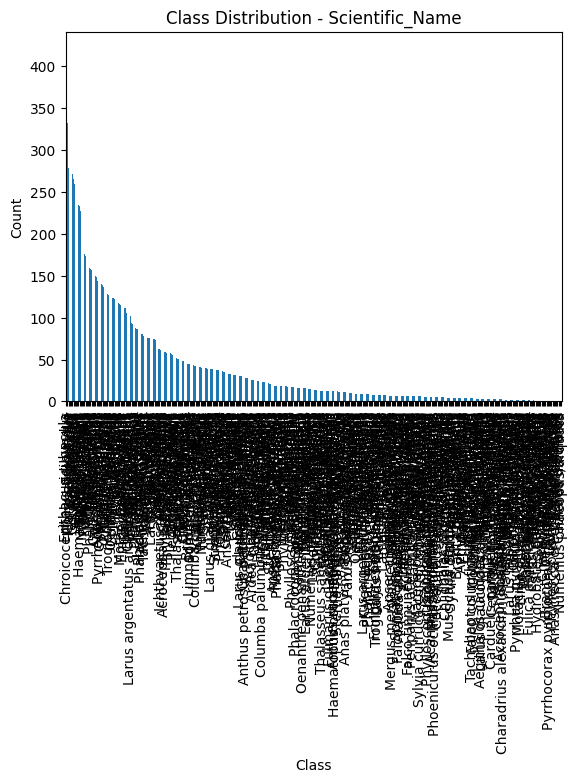

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False)

# 1️⃣ Print column names so you can choose the class column
print("Columns in the dataset:\n")
print(df.columns)

# 2️⃣ Example: Replace 'Scientific_Name' with the column you want to analyze
column_name = 'Scientific_Name'   # ← change this to your desired column

print(f"\nClass Distribution for '{column_name}':\n")
print(df[column_name].value_counts())

# 3️⃣ Plot class distribution
df[column_name].value_counts().plot(kind='bar')
plt.title(f"Class Distribution - {column_name}")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [19]:
df['Scientific_Name'].value_counts()

,count
Scientific_Name,
Erithacus rubecula,420
Chroicocephalus ridibundus,332
Corvus frugilegus,278
Larus argentatus,276
Cygnus olor,273
...,...
Anas crecca crecca x carolinensis,1
Chordeiles minor,1
Ardea alba alba,1


In [17]:
df['Locality'].value_counts()

,count
Locality,
Rogerstown Estuary--Turvey Hide,464
East Coast NR,438
Rogerstown Estuary--North Hide,381
St. Stephen's Green,376
Lough Atalia,331
...,...
Shinrone,1
Tom Clarke Bridge,1
Dublin--Merchant's Arch,1


In [21]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load dataset
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False)

# Step 3: Show columns so you can pick a target
print("Dataset Columns:\n", df.columns)

# ★ IMPORTANT: Set your target column (must be numeric)
target_column = "target_H5_HPAI"   # <-- CHANGE THIS

# Step 3: Convert target column to numeric
df[target_column] = pd.to_numeric(df[target_column], errors='coerce')

# Identify columns with all NaN values and drop them
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill NaN values in numeric columns with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Define features (X) and target (y)
X = df.drop(target_column, axis=1)
y = df[target_column]

# Step 6: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Train KNN model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Step 9: Predict
y_pred = knn.predict(X_test_scaled)

# Step 10: Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Dataset Columns:
 Index(['_id', 'Scientific_Name', 'Common_Name', 'Date', 'Year', 'Month', 'Day',
       'Time', 'Country', 'Country_State_County', 'State', 'County',
       'Locality', 'Latitude', 'Longitude', 'Parent_Species',
       'target_H5_HPAI'],
      dtype='object')
Mean Squared Error (MSE): 0.08
R² Score: 0.36


In [23]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load dataset (using the correct file path)
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False)

# Ensure 'value' column exists for subsequent steps, or identify a suitable target
# If 'value' is not in the dataset, you'll need to choose an appropriate target column.
# Based on previous successful executions, 'target_H5_HPAI' seems like a good candidate.
# For now, I'll assume 'target_H5_HPAI' is the intended target.

# Step 3: Handle missing values and numeric conversion
# Convert the target column to numeric first, coercing errors
if 'target_H5_HPAI' in df.columns:
    df['target_H5_HPAI'] = pd.to_numeric(df['target_H5_HPAI'], errors='coerce')
else:
    print("Warning: 'target_H5_HPAI' column not found. Please adjust target column.")

# Identify columns with all NaN values and drop them
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill remaining NaN values with column mean for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Define features (X) and target (y)
# Assuming 'target_H5_HPAI' is the target column based on previous context
target_column = 'target_H5_HPAI'
X = df.drop(target_column, axis=1)
y = df[target_column]

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Build Neural Network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)  # Output layer (for regression)
])

# Step 9: Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Step 10: Train model
history = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test),
                    epochs=50, batch_size=32, verbose=1)

# Step 11: Predict and evaluate
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n✅ Mean Squared Error (MSE): {mse:.2f}")
print(f"✅ R² Score: {r2:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1494 - mae: 0.2622 - val_loss: 0.1124 - val_mae: 0.2327
Epoch 2/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1137 - mae: 0.2322 - val_loss: 0.1079 - val_mae: 0.2345
Epoch 3/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1088 - mae: 0.2258 - val_loss: 0.1046 - val_mae: 0.2250
Epoch 4/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1032 - mae: 0.2197 - val_loss: 0.1008 - val_mae: 0.2160
Epoch 5/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1016 - mae: 0.2172 - val_loss: 0.0954 - val_mae: 0.2010
Epoch 6/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0933 - mae: 0.2049 - val_loss: 0.0940 - val_mae: 0.2177
Epoch 7/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0894 - mae: 0.1998 - val_loss: 0.0903 - val_mae: 0.2062
Epoch 8/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0859 - mae: 0.1954 - val_loss: 0.0876 - val_mae: 0.1939
Epoch 9/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

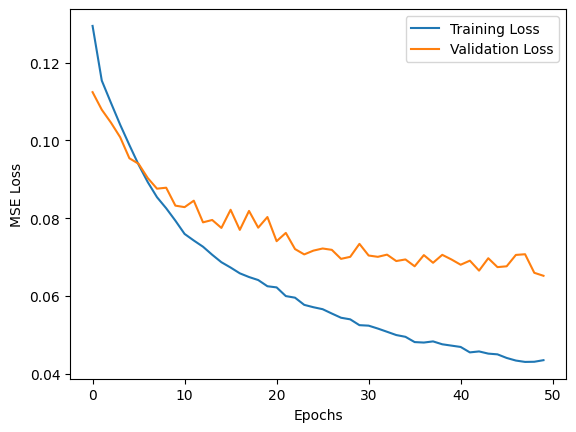

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


In [26]:
# Step 1: Import all necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load and preprocess dataset
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False)

# Show columns so user can choose target
print("Columns in your dataset:\n", df.columns)

# ★ IMPORTANT: Set your target column (must be numeric)
target_column = "target_H5_HPAI"   # ← CHANGE THIS

# Convert target to numeric
df[target_column] = pd.to_numeric(df[target_column], errors='coerce')

# Identify and drop columns that have all NaN values
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill numeric NaN values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Define features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: Train SVM model
svm_model = SVR(kernel='linear')   # Faster than RBF
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate SVM
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("4° SVM RESULTS")
print(f"Mean Squared Error (MSE): {mse_svm:.2f}")
print(f"R² Score: {r2_svm:.2f}")

# Step 4: Train Neural Network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, verbose=0)

# Evaluate Neural Network
y_pred_nn = model.predict(X_test_scaled)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("\n🪔 NEURAL NETWORK RESULTS")
print(f"Mean Squared Error (MSE): {mse_nn:.2f}")
print(f"R² Score: {r2_nn:.2f}")

# Step 5: Compare both
comparison = pd.DataFrame({
    'Model': ['SVM', 'Neural Network'],
    'MSE': [mse_svm, mse_nn],
    'R2 Score': [r2_svm, r2_nn]
})

print("\n📊 Model Performance Comparison:\n")
print(comparison)


Columns in your dataset:
 Index(['_id', 'Scientific_Name', 'Common_Name', 'Date', 'Year', 'Month', 'Day',
       'Time', 'Country', 'Country_State_County', 'State', 'County',
       'Locality', 'Latitude', 'Longitude', 'Parent_Species',
       'target_H5_HPAI'],
      dtype='object')
4° SVM RESULTS
Mean Squared Error (MSE): 0.13
R² Score: -0.02


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

🪔 NEURAL NETWORK RESULTS
Mean Squared Error (MSE): 0.07
R² Score: 0.44

📊 Model Performance Comparison:

            Model       MSE  R2 Score
0             SVM  0.133401 -0.022585
1  Neural Network  0.073276  0.438302


In [28]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load dataset (using the correct file path)
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False)

# Step 3: Handle missing and numeric conversions
# The target column needs to be explicitly defined for classification
target_column = 'target_H5_HPAI' # Assuming 'target_H5_HPAI' is the binary target
df[target_column] = pd.to_numeric(df[target_column], errors='coerce')

# Identify columns with all NaN values and drop them, as fillna(mean) won't work for them
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill remaining NaN values with column mean for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Define features (X) and target (y)
X = df.drop(target_column, axis=1)
y = df[target_column]

# Step 6: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Train Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Step 9: Predict
y_pred = log_reg.predict(X_test_scaled)

# Step 10: Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy*100:.2f}%\n")

print("📋 Classification Report:")
# Add zero_division=0 to suppress the warning for undefined metrics
print(classification_report(y_test, y_pred, zero_division=0))

print("🔢 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

✅ Accuracy: 84.36%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2758
           1       0.18      0.00      0.01       503

    accuracy                           0.84      3261
   macro avg       0.51      0.50      0.46      3261
weighted avg       0.74      0.84      0.78      3261

🔢 Confusion Matrix:
[[2749    9]
 [ 501    2]]


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1372 - mae: 0.2637 - val_loss: 0.1126 - val_mae: 0.2322
Epoch 2/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1167 - mae: 0.2394 - val_loss: 0.1063 - val_mae: 0.2320
Epoch 3/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1079 - mae: 0.2270 - val_loss: 0.1098 - val_mae: 0.2442
Epoch 4/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1057 - mae: 0.2249 - val_loss: 0.1015 - val_mae: 0.2250
Epoch 5/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1015 - mae: 0.2190 - val_loss: 0.0961 - val_mae: 0.2084
Epoch 6/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0915 - mae: 0.2039 - val_loss: 0.0924 - val_mae: 0.2147
Epoch 7/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0892 - mae: 0.2037 - val_loss: 0.0898 - val_mae: 0.1970
Epoch 8/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0828 - mae: 0.1916 - val_loss: 0.0873 - val_mae: 0.2040
Epoch 9/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0827 

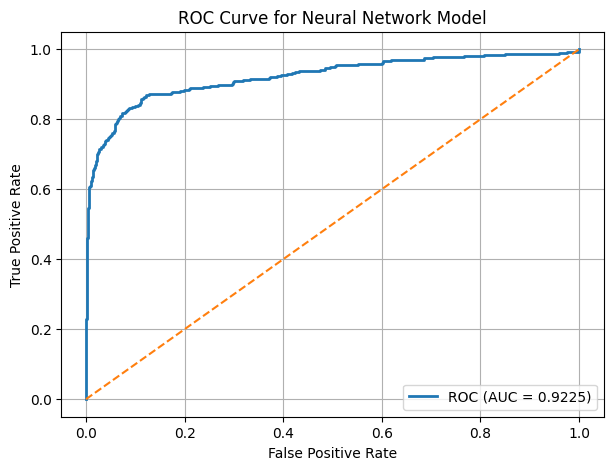

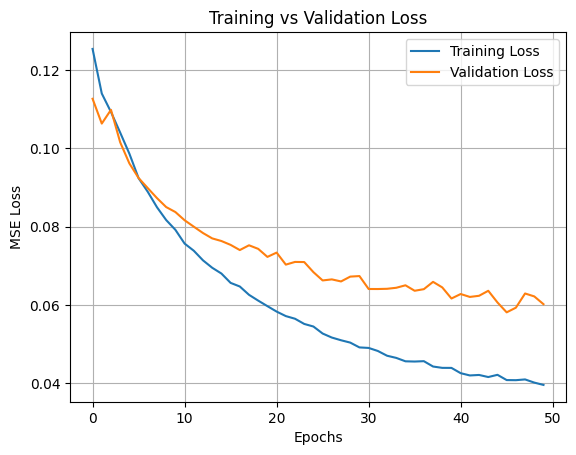

In [36]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load your dataset
# 🔥 CHANGE THE FILE PATH BELOW
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False) # Corrected file path

# Step 3: Handle missing values and numeric conversion
target_column = 'target_H5_HPAI' # Corrected target column name
df[target_column] = pd.to_numeric(df[target_column], errors='coerce')

# Drop columns completely NaN
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill NaN for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Build Neural Network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1) # Output layer for regression
])

# Step 9: Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Step 10: Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50, batch_size=32, verbose=1
)

# Step 11: Prediction & Evaluation (Regression)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n✅ Mean Squared Error (MSE): {mse:.2f}")
print(f"✅ R² Score: {r2:.2f}")

# ---------------------------------------------------
# 🔵 ROC Curve (Regression → Binary Classification)
# ---------------------------------------------------

# For ROC curve, use the original binary y_test as true labels
# and the neural network's regression output as scores
fpr, tpr, thresholds = roc_curve(y_test, y_pred.flatten()) # Use y_test directly as true labels
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.4f}")

# Plot ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Neural Network Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ---------------------------------------------------
# 🔥 Loss Graph (Training vs Validation)
# ---------------------------------------------------

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.show()

Accuracy: 84.36%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2758
           1       0.18      0.00      0.01       503

    accuracy                           0.84      3261
   macro avg       0.51      0.50      0.46      3261
weighted avg       0.74      0.84      0.78      3261

Confusion Matrix:
[[2749    9]
 [ 501    2]]


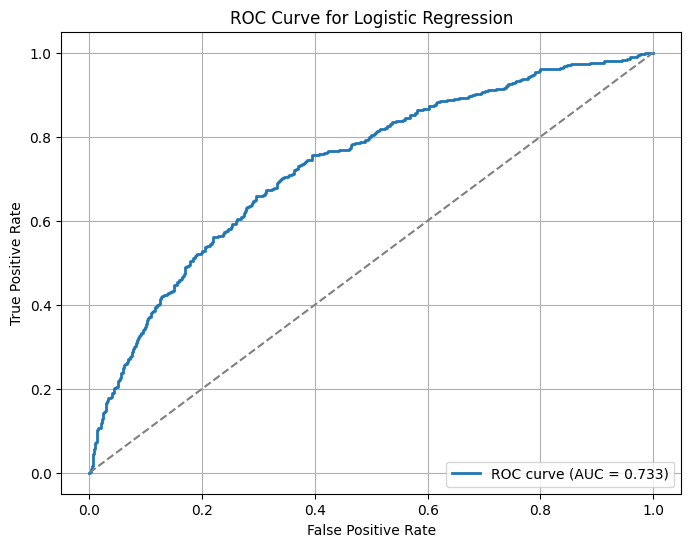

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Step 1: Load YOUR DATASET
# -------------------------------------------------
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False)

# -------------------------------------------------
# Step 2: Handle numeric conversion (optional)
# -------------------------------------------------
# The 'value' column is not in your dataset. 'target_H5_HPAI' is already numeric.

# Drop columns with all NaN
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print("Dropping columns with all NaN values:", cols_to_drop)
    df.drop(columns=cols_to_drop, inplace=True)

# Fill numeric NaN values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# -------------------------------------------------
# Step 3: Encode categorical columns
# -------------------------------------------------
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# -------------------------------------------------
# Step 4: Features & Target
# -------------------------------------------------
TARGET = "target_H5_HPAI"    # ← Corrected target column name

X = df.drop(TARGET, axis=1)
y = df[TARGET]

# -------------------------------------------------
# Step 5: Train-test split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------------------------
# Step 6: Feature Scaling
# -------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------------------------
# Step 7: Train Logistic Regression
# -------------------------------------------------
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# -------------------------------------------------
# Step 8: Predict
# -------------------------------------------------
y_pred = log_reg.predict(X_test_scaled)

# -------------------------------------------------
# Step 9: Evaluation
# -------------------------------------------------
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -------------------------------------------------
# Step 10: MULTICLASS ROC CURVE (Adjusted for binary target)
# -------------------------------------------------
# Ensure y_test contains both classes for ROC calculation
if y.nunique() < 2:
    print("\nWarning: Target column has less than 2 unique classes for ROC curve calculation.")
else:
    # For binary classification, roc_curve expects true labels and scores for the positive class
    # predict_proba returns probabilities for each class [prob_0, prob_1]
    y_score = log_reg.predict_proba(X_test_scaled)[:, 1] # Get probabilities for the positive class (1)

    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve for Logistic Regression")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

all comparesion

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 ROC AUC COMPARISON (Binary Classification)
KNN Classifier         : 0.8510
Logistic Regression    : 0.6959
Neural Network         : 0.9019


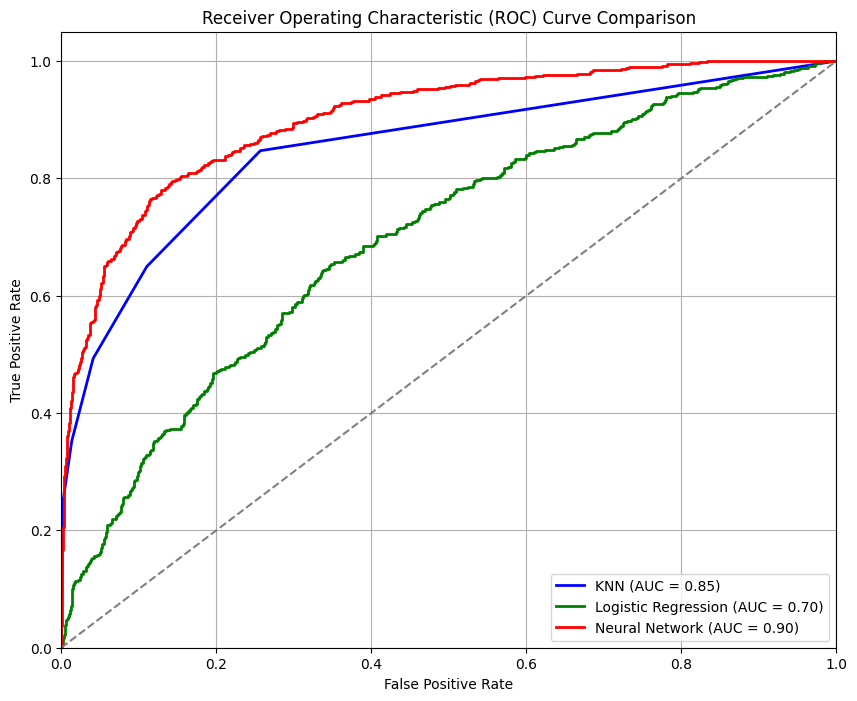


 BEST MODEL: Neural Network (AUC = 0.9019)


In [42]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier # For classification
from sklearn.linear_model import LogisticRegression # For classification
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from itertools import cycle

# ----------------------------------------------------------
# STEP 1: LOAD + CLEAN DATA
# ----------------------------------------------------------
file_path = "/content/Avian Influenza (HPAI).csv" # <-- CORRECTED FILE PATH
df = pd.read_csv(file_path, low_memory=False)

# Define the target column - it's already binary (0 or 1)
TARGET_COLUMN = "target_H5_HPAI" # <-- CORRECTED TARGET COLUMN

# Convert target to numeric (should already be)
df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")

# Drop columns with all NaN values
cols_nan = df.columns[df.isnull().all()].tolist()
if cols_nan:
    df.drop(columns=cols_nan, inplace=True)

# Fill remaining NaN values with mean (only for numeric columns)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode categorical columns (object type)
le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Define features (X) and target (y) for classification
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# Ensure target has at least two unique classes for ROC calculation
if y.nunique() < 2:
    print(f"Warning: Target column '{TARGET_COLUMN}' has less than 2 unique values. Skipping ROC curve calculations.")
    mean_knn_auc = np.nan
    mean_log_auc = np.nan
    auc_nn = np.nan
else:
    # Split dataset into training and testing sets, ensuring stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ----------------------------------------------------------
    # STEP 2: MODEL 1 — KNN Classifier
    # ----------------------------------------------------------
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    knn_proba = knn.predict_proba(X_test_scaled)

    # ROC for binary classification (assuming 1 is the positive class)
    fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_proba[:, 1])
    mean_knn_auc = auc(fpr_knn, tpr_knn)

    # ----------------------------------------------------------
    # STEP 3: MODEL 2 — Logistic Regression
    # ----------------------------------------------------------
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train_scaled, y_train)
    log_proba = log_reg.predict_proba(X_test_scaled)

    # ROC for binary classification (assuming 1 is the positive class)
    fpr_log, tpr_log, _ = roc_curve(y_test, log_proba[:, 1])
    mean_log_auc = auc(fpr_log, tpr_log)

    # ----------------------------------------------------------
    # STEP 4: MODEL 3 — Neural Network
    # ----------------------------------------------------------
    # Build NN for binary classification
    nn = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid') # Sigmoid for binary classification
    ])
    nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Binary crossentropy loss

    nn.fit(X_train_scaled, y_train, epochs=15, batch_size=32, verbose=0)

    nn_scores = nn.predict(X_test_scaled).flatten()
    fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_scores)
    auc_nn = auc(fpr_nn, tpr_nn)

    # ----------------------------------------------------------
    # STEP 5: PRINT COMPARISON & PLOT ROC CURVES
    # ----------------------------------------------------------

    print("\n========================")
    print(" ROC AUC COMPARISON (Binary Classification)")
    print("========================")

    print(f"KNN Classifier         : {mean_knn_auc:.4f}")
    print(f"Logistic Regression    : {mean_log_auc:.4f}")
    print(f"Neural Network         : {auc_nn:.4f}")

    plt.figure(figsize=(10, 8))
    plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label=f'KNN (AUC = {mean_knn_auc:.2f})')
    plt.plot(fpr_log, tpr_log, color='green', lw=2, label=f'Logistic Regression (AUC = {mean_log_auc:.2f})')
    plt.plot(fpr_nn, tpr_nn, color='red', lw=2, label=f'Neural Network (AUC = {auc_nn:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    best_list = []
    if not np.isnan(mean_knn_auc): best_list.append(("KNN", mean_knn_auc))
    if not np.isnan(mean_log_auc): best_list.append(("Logistic Regression", mean_log_auc))
    if not np.isnan(auc_nn):       best_list.append(("Neural Network", auc_nn))

    if best_list:
        best_model = max(best_list, key=lambda x: x[1])
    else:
        best_model = ("None", np.nan)

    print("\n========================")
    print(f" BEST MODEL: {best_model[0]} (AUC = {best_model[1]:.4f})")
    print("========================")

In [49]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load dataset (sample for speed)
df = pd.read_csv("/content/Avian Influenza (HPAI).csv", low_memory=False)

# Step 3: Handle missing and numeric conversions
# The target column 'target_H5_HPAI' is already numeric and doesn't need 'pd.to_numeric' here.
# 'value' is not a column in your dataset.

# Identify and drop columns with all NaN values
cols_to_drop = df.columns[df.isnull().all()].tolist()
if cols_to_drop:
    print(f"Dropping columns with all NaN values: {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)

# Fill remaining NaN for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 4: Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Step 5: Features & Target
# The column 'location_type' is not in your dataset. Using 'target_H5_HPAI' as determined previously.
X = df.drop('target_H5_HPAI', axis=1)
y = df['target_H5_HPAI']

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Train model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Step 9: Predict
y_pred = log_reg.predict(X_test_scaled)

# Step 10: Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy*100:.2f}%\n")

print("📋 Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("🔢 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# =====================================================
# STEP 11: LIME EXPLANATION
# =====================================================

!pip install lime --quiet
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Convert scaled data
X_train_np = X_train_scaled
X_test_np = X_test_scaled

# Create LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=X.columns.tolist(),
    class_names=log_reg.classes_.astype(str),
    mode='classification'
)

# Select a test instance to explain
sample_index = 0
sample = X_test_np[sample_index]

# Generate explanation
exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=log_reg.predict_proba
)

# Display inside notebook
# Note: exp.show_in_notebook() will render an HTML widget which cannot be directly represented in JSON.
# You would typically see this output in a live Jupyter/Colab environment.
# For a text-based output, we'll print the explanation list.

# Console output
print("\nLIME Explanation for Test Sample:", sample_index)
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

✅ Accuracy: 84.36%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2758
           1       0.18      0.00      0.01       503

    accuracy                           0.84      3261
   macro avg       0.51      0.50      0.46      3261
weighted avg       0.74      0.84      0.78      3261

🔢 Confusion Matrix:
[[2749    9]
 [ 501    2]]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done

LIME Explanation for Test Sample: 0
State <= -0.21: 0.1050
Country_State_County <= -0.56: -0.0510
County <= -0.55: 0.0439
0.49 < Longitude <= 0.94: 0.0425
Time > 0.75: 0.0346
Locality > 0.87: 0.0282
-0.70 < Scientific_Name <= -0.16: 0.0188
-0.68 < Parent_Species <= -0.12: 0.0175
-0.78 < Common_Name <= -0.12: 0.0087
-0.58 < Month <= 0.09: -0.0085


Generating ICE + PDP plot for feature: _id


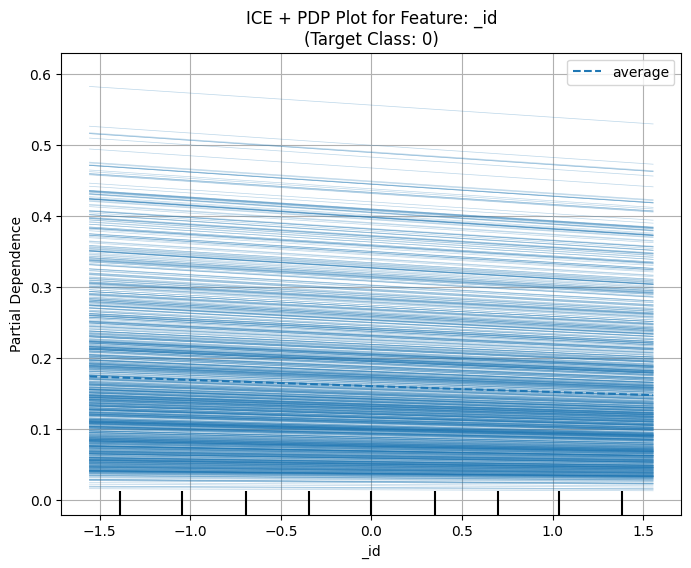

In [50]:
# ================================
# STEP 12: ICE + PDP PLOT
# ================================

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Select ANY feature from your dataset
# Example: Use the first feature
feature_to_plot = X.columns[0]

print(f"Generating ICE + PDP plot for feature: {feature_to_plot}")

# Convert feature name to column index for the estimator
feature_index = X.columns.get_loc(feature_to_plot)

# Select a target class from logistic regression classes
# You can choose log_reg.classes_[1] or others
target_class_to_plot = log_reg.classes_[0]

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Generate ICE + PDP plot
PartialDependenceDisplay.from_estimator(
    estimator=log_reg,
    X=X_train_scaled,
    features=[feature_index],
    kind="both",             # PDP + ICE curves
    target=target_class_to_plot,
    ax=ax
)

plt.title(f"ICE + PDP Plot for Feature: {feature_to_plot}\n(Target Class: {target_class_to_plot})")
plt.xlabel(feature_to_plot)
plt.ylabel("Partial Dependence")
plt.grid(True)
plt.show()


Generating PDP for feature: _id


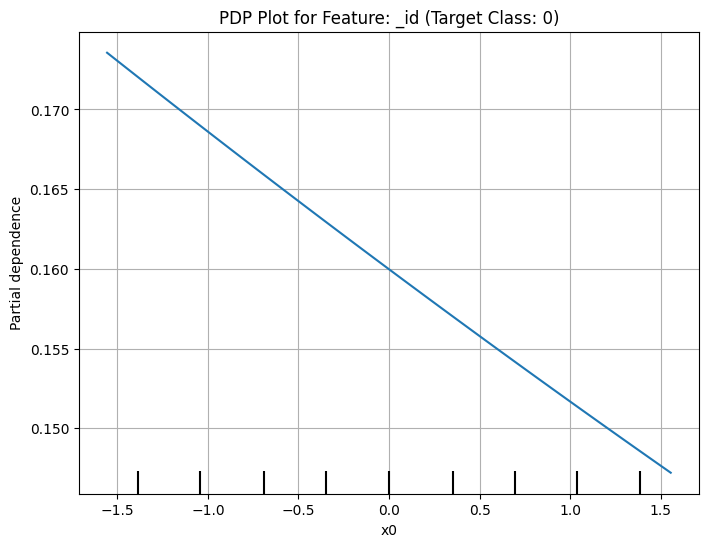

In [51]:
# ================================
# PARTIAL DEPENDENCE PLOT (PDP)
# ================================

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Choose any feature from your dataset
feature_to_plot = X.columns[0]   # You can change to X.columns[5], etc.

print(f"Generating PDP for feature: {feature_to_plot}")

fig, ax = plt.subplots(figsize=(8, 6))

# Pick a target class (for multiclass logistic regression)
target_class_to_plot = log_reg.classes_[0]   # You may change to classes_[1], classes_[2], etc.

PartialDependenceDisplay.from_estimator(
    estimator=log_reg,
    X=X_train_scaled,
    features=[X.columns.get_loc(feature_to_plot)],
    ax=ax,
    target=target_class_to_plot
)

plt.title(f"PDP Plot for Feature: {feature_to_plot} (Target Class: {target_class_to_plot})")
plt.grid(True)
plt.show()
